Vamos a realizar diferentes procesos de mapeo, filtrado y reducción sobre los datos de las viviendas que hemos venido trabajando.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

data=pd.read_excel('https://www.robertohincapie.com/data/datos_viviendas1.xlsx')
data.head()

,Cod_Inmueble,Barrio,Precio,Antiguedad,Area_Construida,Area_Privada,Valor_Admon,Parqueaderos,Habitaciones,Baños,Estrato
0,11318-M3058418,Castropol/Poblado,518000000,Entre 0 y 5 años,110.0,122.0,377000.0,1,4,3,6.0
1,11318-M3021864,Belen/Malibu,382000000,Entre 0 y 5 años,64.0,64.0,190000.0,1,2,3,5.0
2,11318-M3058231,Laureles,845000000,Entre 0 y 5 años,137.0,137.0,530000.0,2,3,4,5.0
3,13155-M3070155,EL POBLADO DE SANTA MARIA DE LOS ANGELES,705000000,Entre 0 y 5 años,123.0,123.0,600000.0,2,3,2,6.0
4,2364-M3070004,El Tesoro,1250000000,Remodelado,232.0,232.0,680000.0,2,3,5,6.0


In [ ]:
#Mapeo 1: Vamos a calcular una nueva columna que tiene el precio por metro cuadrado
data['ValorPorMetroCuadrado']=data['Precio']/data['Area_Construida']

#Mapeo 2: Vamos a reemplazar los nombres de los barrios por nombres correctos.
data['Barrio']=data['Barrio'].replace({'Castropol/Poblado':'Poblado','Belen/Malibu':'Belén','Laureles':'Laureles','EL POBLADO DE SANTA MARIA DE LOS ANGELES':'Poblado',
'El Tesoro':'Poblado','san Germán':'Robledo','EL TESORO':'Poblado','EL PESEBRE':'Robledo','EL POBLADO':'Poblado','Conquistadores':'Conquistadores',
'LOS BALSOS':'Poblado','La Calera':'Poblado','Calasanz':'Calasanz','BELEN RODEO ALTO':'Belén','El Poblado':'Poblado','Castropol':'Poblado',
'Ciudad Del Río':'Poblado','poblado':'Poblado','La Candelaria':'Centro', 'Loma De Los Bernal':'Belén', 'LA LINDE':'Poblado',
'San Lucas':'Poblado', 'Los Balsos':'Poblado', 'La Pilarica':'Robledo', 'CAMPESTRE':'Poblado', 'Poblado':'Poblado','ALTOS DEL POBLADO':'Poblado',
'lalinde':'Poblado','Balsos':'Poblado', 'LA FLORIDA':'Poblado','LOS BALSOS NO 1':'Poblado', 'Las Palmas':'Poblado', 'Loma del Indio':'Poblado',
'POBLADO LA FRONTERA':'Poblado', 'Conquistadores/occidente':'Conquistadores', 'Los Parra':'Poblado','Belen':'Belén', 'Medellín':'Medellín',
'Los colores':'Los Colores', 'Sabaneta':'Sabaneta','EL POBLADO LA LINDE':'Poblado', 'Los Balsos - El Poblado':'Poblado', 'LA AMERICA':'La América',
'Santa Maria De Los':'Poblado', 'LAURELES':'Laureles'})

In [ ]:
data['Barrio'].unique()

array(['Poblado', 'Belén', 'Laureles', 'Robledo', 'Conquistadores',
       'Calasanz', 'Centro', 'Medellín', 'Los Colores', 'Sabaneta',
       'La América'], dtype=object)

In [ ]:
#Filtrado No. 1: Vamos a filtrar las casas de uno de los barrios.
#Reducción No. 1: Vamos a calcular el valor promedio del precio de las casas filtradas
data_poblado=data[data['Barrio']=='Poblado']
print('Precio/m2 promedio del Poblado: ', data_poblado['ValorPorMetroCuadrado'].mean())

Precio/m2 promedio del Poblado:  5073027.693311881


In [ ]:
#Pero si queremos hacer esto para todos los barrios disponibles, podemos hacer un ciclo, guardando los valores.
df2=data.groupby(by='Barrio').agg({'ValorPorMetroCuadrado':'mean'}).sort_values(by='ValorPorMetroCuadrado')
df2
#df2.plot.barh()
#plt.xlabel('Precio por metro cuadrado')

,ValorPorMetroCuadrado
Barrio,
Centro,3.258427e+06
Sabaneta,3.698387e+06
Medellín,3.793103e+06
Calasanz,3.846154e+06
Robledo,4.258751e+06
Los Colores,4.776119e+06
Belén,4.787698e+06
La América,5.000000e+06
Poblado,5.073028e+06


In [ ]:
#Pero si queremos hacer esto para todos los barrios disponibles, podemos hacer un ciclo, guardando los valores.
df2=data.groupby(by='Antiguedad').agg({'ValorPorMetroCuadrado':'mean'}).sort_values(by='ValorPorMetroCuadrado')
df2['ValorPorMetroCuadrado']=df2['ValorPorMetroCuadrado'].map("${:,.0f}".format)
df2
#df2.plot.bar()
#df2.loc[['Entre 10 y 20 años','Remodelado']]

,ValorPorMetroCuadrado
Antiguedad,
Más de 20 años,"$4,118,239"
Entre 10 y 20 años,"$4,397,629"
Remodelado,"$4,754,483"
Entre 5 y 10 años,"$5,265,921"
Entre 0 y 5 años,"$5,526,095"


In [ ]:
df2=data.groupby(by=['Barrio','Antiguedad']).agg({'ValorPorMetroCuadrado':['mean', 'max', 'min'],'Area_Construida':['mean', 'count']})#.sort_values(by=['Barrio','Antiguedad'],ascending=[False, False])
df2

ValorPorMetroCuadrado                \
                                                   mean           max   
Barrio         Antiguedad                                               
Belén          Entre 0 y 5 años            5.484375e+06  5.968750e+06   
               Entre 5 y 10 años           3.650794e+06  3.650794e+06   
               Remodelado                  4.531250e+06  4.531250e+06   
Calasanz       Entre 10 y 20 años          3.846154e+06  3.846154e+06   
Centro         Más de 20 años              3.258427e+06  3.258427e+06   
Conquistadores Entre 0 y 5 años            5.597938e+06  5.597938e+06   
               Entre 10 y 20 años          4.822951e+06  4.900000e+06   
La América     Entre 5 y 10 años           5.000000e+06  5.000000e+06   
Laureles       Entre 0 y 5 años            5.197423e+06  6.167883e+06   
               Entre 10 y 20 años          5.245238e+06  5.357143e+06   
               Más de 20 años              4.725409e+06  4.780488e+06   
Los Colores    Entre 10 y 20 años          4.776119e+06  4.776119e+06   
Medellín       Más de 20 años              3.793103e+06  3.793103e+06   
Poblado        Entre 0 y 5 años            5.815885e+06  8.181818e+06   
               Entre 10 y 20 años          4.332338e+06  6.380952e+06   
               Entre 5 y 10 años           5.391325e+06  8.125000e+06   
               Más de 20 años              4.114564e+06  5.064103e+06   
               Remodelado                  5.014426e+06  5.387931e+06   
Robledo        Entre 0 y 5 años            5.118421e+06  5.118421e+06   
               Entre 10 y 20 años          3.200000e+06  3.200000e+06   
               Remodelado                  4.457831e+06  4.457831e+06   
Sabaneta       Entre 0 y 5 años            3.698387e+06  3.701613e+06   

                                                Area_Construida        
                                            min            mean count  
Barrio         Antiguedad                                              
Belén          Entre 0 y 5 años    5.000000e+06       74.000000     2  
               Entre 5 y 10 años   3.650794e+06       63.000000     1  
               Remodelado          4.531250e+06       64.000000     1  
Calasanz       Entre 10 y 20 años  3.846154e+06       78.000000     1  
Centro         Más de 20 años      3.258427e+06       89.000000     1  
Conquistadores Entre 0 y 5 años    5.597938e+06       97.000000     1  
               Entre 10 y 20 años  4.745902e+06       86.000000     2  
La América     Entre 5 y 10 años   5.000000e+06       50.000000     1  
Laureles       Entre 0 y 5 años    4.380952e+06      109.428571     7  
               Entre 10 y 20 años  5.133333e+06      201.000000     2  
               Más de 20 años      4.670330e+06      193.500000     2  
Los Colores    Entre 10 y 20 años  4.776119e+06       67.000000     1  
Medellín       Más de 20 años      3.793103e+06      232.000000     1  
Poblado        Entre 0 y 5 años    3.125000e+06      167.500000    22  
               Entre 10 y 20 años  2.786885e+06      195.388889    18  
               Entre 5 y 10 años   3.030303e+06      164.790000    15  
               Más de 20 años      2.891566e+06      127.125000     8  
               Remodelado          4.640921e+06      189.800000     2  
Robledo        Entre 0 y 5 años    5.118421e+06       76.000000     1  
               Entre 10 y 20 años  3.200000e+06       55.000000     1  
               Remodelado          4.457831e+06       83.000000     1  
Sabaneta       Entre 0 y 5 años    3.695161e+06       62.000000     2

<Axes: ylabel='Antiguedad,Barrio'>

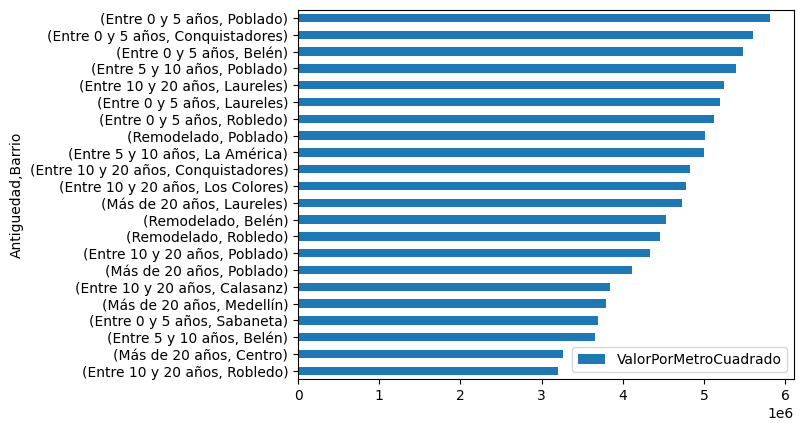

In [ ]:
data.groupby(by=['Antiguedad','Barrio']).agg({'ValorPorMetroCuadrado':'mean'}).sort_values(by='ValorPorMetroCuadrado').plot.barh()

In [ ]:
df3=data.groupby(by=['Antiguedad','Barrio']).agg({'ValorPorMetroCuadrado':['mean','std']}).fillna(0)
df3

ValorPorMetroCuadrado              
                                                   mean           std
Antiguedad         Barrio                                            
Entre 0 y 5 años   Belén                   5.484375e+06  6.850097e+05
                   Conquistadores          5.597938e+06  0.000000e+00
                   Laureles                5.197423e+06  7.419446e+05
                   Poblado                 5.815885e+06  1.258998e+06
                   Robledo                 5.118421e+06  0.000000e+00
                   Sabaneta                3.698387e+06  4.561979e+03
Entre 10 y 20 años Calasanz                3.846154e+06  0.000000e+00
                   Conquistadores          4.822951e+06  1.089640e+05
                   Laureles                5.245238e+06  1.582572e+05
                   Los Colores             4.776119e+06  0.000000e+00
                   Poblado                 4.332338e+06  8.436487e+05
                   Robledo                 3.200000e+06  0.000000e+00
Entre 5 y 10 años  Belén                   3.650794e+06  0.000000e+00
                   La América              5.000000e+06  0.000000e+00
                   Poblado                 5.391325e+06  1.147236e+06
Más de 20 años     Centro                  3.258427e+06  0.000000e+00
                   Laureles                4.725409e+06  7.789356e+04
                   Medellín                3.793103e+06  0.000000e+00
                   Poblado                 4.114564e+06  7.712984e+05
Remodelado         Belén                   4.531250e+06  0.000000e+00
                   Poblado                 5.014426e+06  5.282156e+05
                   Robledo                 4.457831e+06  0.000000e+00